# Project 2 — Part I (b): Can the disease exhibit cyclical behaviour?

*Can the disease exhibit cyclical behaviour?*

A closed SIR epidemic ($S\to I\to R$) burns out after a single wave and **cannot** oscillate: with
permanent immunity, susceptibles are never replenished, so once enough people are immune the
disease dies out for good. (Making $\beta$ seasonal does not help — without replenishment it still
burns out.) The minimal change that produces cyclical behaviour is to let immunity **wane**
($R\to S$ at rate $\omega$): a single extra transition added to the refined Binomial scheme of
Section 0.2 (`simulate_sirs` in [`sir_model.py`](sir_model.py)).

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))
from sir_model import simulate_sir, simulate_sirs

IMAGES = Path("..") / "Images"
IMAGES.mkdir(exist_ok=True)

# large population so the cycles are not washed out by stochastic extinction
N, beta, gamma, I0 = 500_000, 0.5, 0.1, 100      # R0 = beta/gamma = 5
omega = 1 / 200                                  # waning: immunity lasts ~200 days
print(f"N={N}, beta={beta}, gamma={gamma}, R0={beta/gamma:.0f}, omega=1/{int(1/omega)} per day")

N=500000, beta=0.5, gamma=0.1, R0=5, omega=1/200 per day


## Closed SIR vs waning immunity

The basic SIR burns out after one wave (left). With waning immunity the disease persists and
approaches an endemic equilibrium through **damped oscillations** — recurring, decaying waves as
susceptibles are replenished and then depleted again (right).

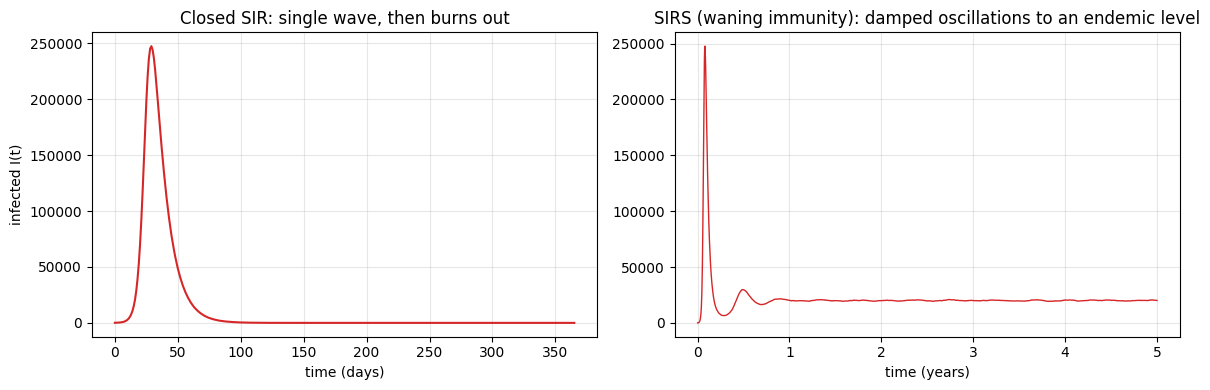

closed SIR: I at end = 0 (burned out)
SIRS waning: endemic mean I ~ 20100


In [2]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# closed SIR (the model from question (a)): single wave, burns out
tc, Sc, Ic, Rc = simulate_sir(N, beta, gamma, I0, T=365, dt=1.0, rng=np.random.default_rng(1))
ax[0].plot(tc, Ic, color="tab:red", lw=1.5)
ax[0].set_title("Closed SIR: single wave, then burns out")
ax[0].set_xlabel("time (days)"); ax[0].set_ylabel("infected I(t)"); ax[0].grid(alpha=0.3)

# SIRS: one extra transition (waning immunity) -> damped oscillations to an endemic level
ts, Ss, Is, Rs = simulate_sirs(N, beta, gamma, omega, I0=I0, T=365*5, dt=1.0,
                               rng=np.random.default_rng(1))
ax[1].plot(ts / 365, Is, color="tab:red", lw=1.0)
ax[1].set_title("SIRS (waning immunity): damped oscillations to an endemic level")
ax[1].set_xlabel("time (years)"); ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(IMAGES / "Proj2_PartB_burnout_vs_endemic.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"closed SIR: I at end = {int(Ic[-1])} (burned out)")
print(f"SIRS waning: endemic mean I ~ {int(Is[ts > 365*3].mean())}")

## Conclusion

Yes, but not with the basic model: a closed SIR burns out after one wave. The minimal modification
that yields cyclical behaviour is **waning immunity** — a single $R\to S$ transition — which makes
the disease endemic and produces damped oscillations toward a steady level. An external seasonal
driver would turn these damped oscillations into sustained cycles, and demographic turnover
(births/deaths) plays the same replenishing role as waning immunity.

---

**AI Declaration:** This notebook's code was refactored and commented with AI assistance. All results and conclusions were independently verified by a human supervisor.